## Imports And Library Loading

In [2]:
import datetime
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
import timm
from torchvision import transforms
import tqdm
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, precision_recall_curve, average_precision_score
)
from collections import defaultdict, OrderedDict
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import datetime
import json

## Dataset Class And Validation

In [3]:
class ImageDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data = ImageFolder(data_dir, transform=transform)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]
    
    @property
    def classes(self):
        return self.data.classes
    

In [4]:
# Dataset Directory Assignment
train_image_dataset = ImageDataset(data_dir=r"C:\Users\Shohan\Desktop\DeepFakeImg\MyLearning\dataset\train")
test_image_dataset = ImageDataset(data_dir=r"C:\Users\Shohan\Desktop\DeepFakeImg\MyLearning\dataset\test")
val_image_dataset = ImageDataset(data_dir=r"C:\Users\Shohan\Desktop\DeepFakeImg\MyLearning\dataset\val")

In [5]:
# Print the number of images in each dataset
len(train_image_dataset), len(test_image_dataset), len(val_image_dataset) 

(25696, 3213, 3212)

0


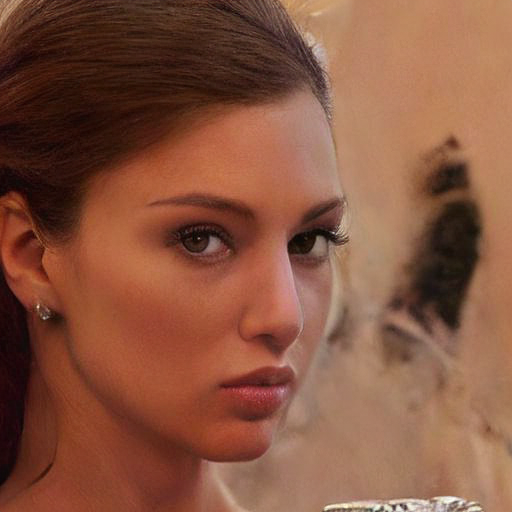

In [6]:
# Test Itration
image, label = test_image_dataset[300]
print(label)
image

In [7]:
# Dataset Class Index Validation

train_data_dir = train_image_dataset.data.root
val_data_dir = val_image_dataset.data.root
test_data_dir = test_image_dataset.data.root

target_to_class_train = {v : k for k, v in ImageFolder(train_data_dir).class_to_idx.items()}
print(target_to_class_train)
target_to_class_val = {v : k for k, v in ImageFolder(val_data_dir).class_to_idx.items()}
print(target_to_class_val)
target_to_class_test = {v : k for k, v in ImageFolder(test_data_dir).class_to_idx.items()}
print(target_to_class_test)


print(train_data_dir)

{0: 'fake', 1: 'real'}
{0: 'fake', 1: 'real'}
{0: 'fake', 1: 'real'}
C:\Users\Shohan\Desktop\DeepFakeImg\MyLearning\dataset\train


In [8]:
# Valuation Dataset Shape and Label

image, label = val_image_dataset[100]
print("Image shape:", image.size)
print("Label:", label)
print("Dataset length:", len(val_image_dataset))

Image shape: (256, 256)
Label: 0
Dataset length: 3212


In [9]:
import torchvision.transforms as transforms
import torch # Needed for torch.rand() for dynamic sharpness

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    # 1. Resizing (usually done first)
    transforms.Resize((256, 256)),

    # 2. Geometric Transformations (operate on PIL Images)
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomApply([transforms.ElasticTransform(alpha=250.0, sigma=15.0)], p=0.2),
    # Choose one RandomPerspective; I'll use the p=0.5 as it was first and not commented out
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),

    # 3. Photometric / Color Transformations (operate on PIL Images)
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5.0)), # Consider adjusting params as discussed earlier

    # Correct way to apply random sharpness/blur
    transforms.RandomApply([
        transforms.RandomAdjustSharpness(sharpness_factor=torch.rand(1).item() * 1.5 + 0.25)
        # This will randomly pick a sharpness factor between 0.25 (blurrier) and 1.75 (sharper)
    ], p=0.2), # Apply this random sharpness/blur with a 20% probability


    # 4. Conversion to Tensor (PIL Image -> Tensor)
    transforms.ToTensor(),

    # 5. Normalization (operate on Tensor)
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    ),

    # 6. Tensor-based Augmentations (operate on Tensor, should come after ToTensor and Normalize)
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0),
])

# Don't forget your validation/test transform (no random augmentations)
val_test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


train_dataset = ImageDataset(train_data_dir, train_transform)
val_dataset = ImageDataset(val_data_dir, val_test_transform)
test_dataset = ImageDataset(test_data_dir, val_test_transform)

In [10]:
# Tranformation Check
train_dataset[300]

(tensor([[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          ...,
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],
 
         [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          ...,
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],
 
         [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
          [-1.8044, -1.8044,

In [11]:
# Iterate over the transformed dataset
for image, label in train_dataset:
    break

image.size()

torch.Size([3, 256, 256])

## DataLoder

In [12]:
# train_detaset is the tensor of out train
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

### DenseNet-121

In [14]:
class Densenet121_Builder(nn.Module):
    def __init__(self, num_classes=2, dropout_rate=0.4, use_pretrained=True):
        """
        Initializes a DenseNet-121 model structured like the EfficientNetB0 DeepFakeClassifier.

        Args:
            num_classes (int): The number of output classes (default: 2 for real/deepfake).
            dropout_rate (float): Dropout probability for the classification head.
            use_pretrained (bool): If True, loads a DenseNet-121 model pre-trained on ImageNet.
        """
        super(Densenet121_Builder, self).__init__()

        # 1. Define the base model (DenseNet-121)
        self.base_model = timm.create_model('densenet121', pretrained=use_pretrained)

        # 2. Extract the feature backbone (everything before the final classifier layer)
        # For DenseNet-121, the feature extractor is contained in 'features' attribute,
        # which includes all conv layers, dense blocks, and transition layers,
        # ending with a global average pooling implicitly by the last BatchNorm layer.
        # self.features = self.base_model.features # This is already a nn.Sequential module
        self.features = nn.Sequential(*list(self.base_model.children())[:-1])

        # 3. Determine the output size of the feature extractor.
        # For DenseNet-121, after the 'features' module and its final BatchNorm,
        # the output is 1024 channels, which then passes through an activation
        # before the final classifier. So, the output size is 1024.
        enet_out_size = 1024 # This will be 1024 for DenseNet-121

        # 4. Create the classifier head, including Flatten, Dropout, and Linear layer
        self.classifier = nn.Sequential(
            nn.ReLU(inplace=True),             # DenseNet's features typically end before the final ReLU
            # nn.AdaptiveAvgPool2d((1, 1)),      # Ensure consistent (1,1) spatial dimensions if not already handled
            nn.Flatten(),                      # Flattens the output (e.g., (batch, 1024, 1, 1) to (batch, 1024))
            nn.Dropout(dropout_rate),          # Dropout layer for regularization
            nn.Linear(enet_out_size, num_classes) # Final linear layer for classification
        )

        # Important: If using pretrained, you might want to freeze early layers
        # or fine-tune specific blocks based on your dataset size and task.
        # By default, all parameters are trainable unless explicitly frozen.
        if use_pretrained:
            print("Using pre-trained DenseNet-121 weights.")
            # If you want to freeze the features and only train the classifier:
            # for param in self.features.parameters():
            #     param.requires_grad = False
            # print("Frozen DenseNet-121 feature backbone. Only classifier layers are trainable.")
        else:
            print("Training DenseNet-121 from scratch.")


    def forward(self, x):
        """
        Forward pass through the model.

        Args:
            x (torch.Tensor): Input tensor (image batch).

        Returns:
            torch.Tensor: Output logits from the model.
        """
        x = self.features(x)     # Pass through the feature extraction backbone
        output = self.classifier(x) # Pass through the custom classification head
        return output

In [15]:
# Print the model structure
model = Densenet121_Builder(num_classes=2)
print(model)

Using pre-trained DenseNet-121 weights.
Densenet121_Builder(
  (base_model): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNormAct2d(
        64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): ReLU(inplace=True)
      )
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): DenseBlock(
        (denselayer1): DenseLayer(
          (norm1): BatchNormAct2d(
            64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): ReLU(inplace=True)
          )
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNormAct2d(
            128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): ReLU(inplace=True)

## Configaration Class

In [ ]:
import torch
import tqdm
from collections import defaultdict
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, average_precision_score
from torch.utils.tensorboard import SummaryWriter
import os
import json
import datetime # Added this import for datetime.datetime.now()

# Configuration class to encapsulate all training parameters and paths
class Config:
    def __init__(self,
                 model,
                 optimizer,
                 criterion,
                 val_data_dir,
                 class_names,
                 num_epochs,
                 device,
                 scheduler,
                 test_data_dir,
                 train_data_dir,
                 train_losses,
                 val_losses,
                 train_accuracies,
                 val_accuracies,
                 save_top_k=3, # Default value, can be overridden
                 img_size=256, # Default image size, can be overridden
                 # Removed: early_stop, early_stop_patience, early_stop_min_delta
                ):
        self.model_name = model.__class__.__name__
        # Core training components
        self.img_size = img_size
        self.optimizer_type = optimizer.__class__.__name__,
        self.criterion_type = criterion.__class__.__name__
        self.train_dataset = train_data_dir
        self.test_dataset = test_data_dir
        self.val_dataset = val_data_dir
        self.data_class_names = class_names # Assuming class names are the same across datasets
        self.num_epochs = num_epochs
        self.device_name = device.type if isinstance(device, torch.device) else device
        self.scheduler_name = scheduler.__class__.__name__

        # Data Augmentation and normalization
        self.augment = True

        # Removed: Early stopping configuration (self.early_stop, self.patience_counter, self.early_stop_min_delta)

        # Training and validation metrics (lists to be populated during training)
        self.train_losses = train_losses
        self.val_losses = val_losses
        self.train_accuracies = train_accuracies
        self.val_accuracies = val_accuracies

        # Experiment tracking
        self.timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

        # Paths and directories (dynamically generated)
        model_name_lower = model.__class__.__name__.lower()
        self.exp_name = f"{model_name_lower}_{self.timestamp}"
        self.exp_dir = os.path.join("experiments", self.exp_name)
        self.model_path = os.path.join(self.exp_dir, "best_model.pth")
        self.last_model_path = os.path.join(self.exp_dir, "last_model.pth")
        self.log_dir = os.path.join(self.exp_dir, "logs")
        
        self.save_top_k = save_top_k # Number of best models to save
        self.history_path = os.path.join(self.exp_dir, "history.json")

        # Create experiment directories if they don't exist
        os.makedirs(self.log_dir, exist_ok=True)
        print(f"Experiment directory created: {self.exp_dir}")
        print(f"Model will be saved to: {self.model_path}")
        print(f"Last model will be saved to: {self.last_model_path}")
        print(f"TensorBoard logs will be saved to: {self.log_dir}")

    def save(self):
        """Save configuration to experiment directory"""
        config_dict = {k:v for k,v in vars(self).items() if not k.startswith('__') and k != 'class_names'}
        with open(os.path.join(self.exp_dir, "config.json"), 'w') as f:
            json.dump(config_dict, f, indent=2)

## Tesorboard Plots Function

In [16]:
# Function to plot training history and save the plots
import matplotlib.pyplot as plt

def plot_training_history(history, cfg):
    """Plot training metrics and save to experiment directory"""
    plt.figure(figsize=(18, 12))
    
    # Plot loss
    plt.subplot(2, 2, 1)
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['val_loss'], label='Validation')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    # Plot accuracy
    plt.subplot(2, 2, 2)
    plt.plot(history['train_acc'], label='Train')
    plt.plot(history['val_acc'], label='Validation')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Plot AUC
    plt.subplot(2, 2, 3)
    plt.plot(history['val_auc'], label='Validation')
    plt.title('Validation AUC')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    
    # Plot learning rate
    plt.subplot(2, 2, 4)
    plt.plot(history['lr'])
    plt.title('Learning Rate')
    plt.xlabel('Epoch')
    plt.ylabel('LR')
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.exp_dir, "training_metrics.png"))
    plt.close()

def plot_evaluation_report(model, loader, cfg, phase="val"):
    """Generate comprehensive evaluation report with visualizations"""
    
    # Ensure cfg.class_names is available and correctly set (e.g., ['fake', 'real'])
    # This is handled by your Config class if you set it up with target_to_class_train
    if not hasattr(cfg, 'class_names') or not cfg.class_names:
        print("Warning: cfg.class_names is not set. Using default ['Class 0', 'Class 1'] for report labels.")
        cfg.class_names = ['Class 0', 'Class 1'] # Fallback for plotting

    # Use next(model.parameters()).device to get the device if model is on CUDA/CPU
    # If the model is not yet on a device, you might need to pass the device explicitly from outside.
    # For robust evaluation, ensure the model is on the correct device when evaluate_model is called.
    device_for_eval = next(model.parameters()).device 
    
    metrics, y_true, y_scores, y_pred = evaluate_model(model, loader, device=device_for_eval)
    
    report = {
        'metrics': metrics,
        'confusion_matrix': confusion_matrix(y_true, y_pred).tolist(),
        'classification_report': classification_report(
            y_true, y_pred, target_names=cfg.class_names, output_dict=True
        )
    }
    
    # Ensure experiment directory exists before saving
    os.makedirs(cfg.exp_dir, exist_ok=True) 

    # Save report JSON
    report_path = os.path.join(cfg.exp_dir, f"{phase}_report.json")
    with open(report_path, 'w') as f:
        json.dump(report, f, indent=2)
    print(f"Report for {phase.capitalize()} saved to: {report_path}")
    
    # Plot confusion matrix
    plt.figure(figsize=(6, 6))
    # Convert confusion matrix to a numpy array if it's a list of lists for sns.heatmap
    cm_data = report['confusion_matrix'] # It's already a list of lists from .tolist()
    sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues', 
                xticklabels=cfg.class_names, yticklabels=cfg.class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f"Confusion Matrix ({phase.capitalize()})")
    plt.savefig(os.path.join(cfg.exp_dir, f"{phase}_confusion_matrix.png"))
    plt.close()
    print(f"Confusion Matrix for {phase.capitalize()} saved to: {os.path.join(cfg.exp_dir, f'{phase}_confusion_matrix.png')}")
    
    # Plot PR curve
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision, label=f"AP = {metrics['ap']:.2f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve ({phase.capitalize()})")
    plt.legend()
    plt.savefig(os.path.join(cfg.exp_dir, f"{phase}_pr_curve.png"))
    plt.close()
    print(f"Precision-Recall Curve for {phase.capitalize()} saved to: {os.path.join(cfg.exp_dir, f'{phase}_pr_curve.png')}")

## Main Execution

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau
# from torchsummary import summary # Uncomment if you use summary later
from collections import defaultdict, OrderedDict
import os # Import os for path operations

# --- Assume these imports/definitions exist elsewhere in your project ---
# from your_model_builders_file import EfficientnetB0_Builder, Resnet50_Builder, Densenet121_Builder, MobilenetV3_Builder
# from your_data_loaders_file import train_loader, val_loader # Assuming these are already defined
# from your_data_paths_file import train_data_dir, val_data_dir, test_data_dir, target_to_class_train
# ---------------------------------------------------------------------------------------------------


# Simple training loop
num_epochs = 30 # Set your desired number of epochs here (e.g., 30 as in your comment)
train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# --- MODEL AND OPTIMIZER SETUP ---
# Uncomment the model you want to run
# model = EfficientnetB0_Builder(num_classes=2, dropout_rate=0.4)
# model = Resnet50_Builder(num_classes=2, dropout_rate=0.4)  # Selected Resnet50
model = Densenet121_Builder(num_classes=2, dropout_rate=0.4)
# model = MobilenetV3_Builder(num_classes=2, dropout_rate=0.4)
# -------------------------------------------------------------------------------------
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0007)

# --- LEARNING RATE SCHEDULER SETUP ---
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
# -------------------------------------------------------------------------------------

# Removed: early_stop = True/False, patience = 5, as early stopping logic is no longer used.

cfg = Config(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_data_dir=train_data_dir,
    val_data_dir=val_data_dir,
    test_data_dir=test_data_dir,
    class_names=target_to_class_train,
    num_epochs=num_epochs,
    device=device,
    train_losses=train_losses,
    val_losses=val_losses,
    train_accuracies=train_accuracies,
    val_accuracies=val_accuracies,
    scheduler=scheduler,
    save_top_k=3,
    img_size=256,
    # Removed: early_stop, early_stop_patience, early_stop_min_delta parameters
)

# Tracking Initialization
history = defaultdict(list)
best_metrics = {'auc': 0.0, 'epoch': 0, 'val_loss': float('inf')}
# Removed: early_stop_counter = 0

# Run the training Loop
cfg.save() # Save the configuration to the experiment directory
print("⚙️ Configuration saved to:", os.path.join(cfg.exp_dir, "config.json"))

print("\n🏋️ Starting training...")

final_history, final_best_metrics = training_model(
    num_epochs,
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    scheduler,
    device,
    cfg
)

print(f"\n--- Training Finished ---")
print(f"Best model (based on AUC) achieved AUC: {final_best_metrics['auc']:.4f} at epoch {final_best_metrics['epoch']}")
print(f"\n⚙️ Final training history recorded. Check '{os.path.join(cfg.exp_dir, 'training_history.json')}' for full details.")

plot_training_history(final_history, cfg)
print(f"📁 Training metrics plot saved to: {os.path.join(cfg.exp_dir, 'training_metrics.png')}")

## Evaluation of Valodation and Test Dataset

In [ ]:
def evaluate_model(model, loader, device):
    """
    Evaluates the model on the given loader.

    Args:
        model (torch.nn.Module): The neural network model to evaluate.
        loader (torch.utils.data.DataLoader): DataLoader for the dataset to evaluate.
        device (torch.device): The device (CPU or GPU) to run the evaluation on.

    Returns:
        tuple: A tuple containing:
            - metrics (dict): Dictionary of calculated metrics (accuracy, auc, f1, precision, recall, ap).
            - y_true (list): List of true labels.
            - y_scores (list): List of model's output scores (for positive class if binary).
            - y_pred (list): List of predicted labels.
    """
    model.eval() # Set the model to evaluation mode
    all_labels = []
    all_preds = []
    all_outputs_softmax = []

    with torch.no_grad(): # Disable gradient calculation for evaluation
        for images, labels in tqdm.tqdm(loader, desc="Evaluating Model"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            preds = outputs.argmax(dim=1)
            outputs_softmax = outputs.softmax(dim=1) # Get probabilities

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            # For AUC, AP, we need scores for the positive class (assuming binary classification)
            all_outputs_softmax.extend(outputs_softmax[:, 1].cpu().numpy())

    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_outputs_softmax)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    ap = average_precision_score(all_labels, all_outputs_softmax)

    metrics = {
        'accuracy': accuracy,
        'auc': auc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'ap': ap
    }

    return metrics, all_labels, all_outputs_softmax, all_preds

In [ ]:
# Generate evaluation report for validation set
plot_evaluation_report(model, val_loader, cfg, phase="val")
print(f"📁 Validation evaluation report saved to: {os.path.join(cfg.exp_dir, 'val_report.json')}")
# Add these lines to confirm plot saving
print(f"📁 Validation Confusion Matrix plot saved to: {os.path.join(cfg.exp_dir, 'val_confusion_matrix.png')}")
print(f"📁 Validation PR Curve plot saved to: {os.path.join(cfg.exp_dir, 'val_pr_curve.png')}")


# ... (Code for your main execution cell, including model setup, training call,
# and validation report generation) ...

# --- Add this section to your main execution cell ---

print(f"\nLoading best model from {cfg.model_path} for final test evaluation...")

# Load the best model checkpoint saved during training
# 'model' is your instantiated model object
# 'device' is your torch.device object (CPU or CUDA)
checkpoint = torch.load(cfg.model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

# Set the model to evaluation mode
model.eval()

# Generate and save the comprehensive evaluation report for the test set
print("\n📊 Generating Report for Test Data Set...")
# 'plot_evaluation_report' is your plotting function
# 'test_loader' is the DataLoader you created in step 1
# 'cfg' is your Config object
plot_evaluation_report(model, test_loader, cfg, phase="test")
print(f"📁 Test set evaluation report saved to: {os.path.join(cfg.exp_dir, 'test_report.json')}")
print(f"📁 Test set confusion matrix saved to: {os.path.join(cfg.exp_dir, 'test_confusion_matrix.png')}")
print(f"📁 Test set PR curve saved to: {os.path.join(cfg.exp_dir, 'test_pr_curve.png')}")

# --- End of added section ---

### ROC Gen

In [ ]:
import torch
import torch.nn as nn
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from tqdm import tqdm
import timm

# ----- Define your model class -----


# ----- Load best model -----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Densenet121_Builder(num_classes=2, dropout_rate=0.4) #---------> Change the Model class name Accordingly
checkpoint = torch.load(
    r"C:\Users\Shohan\Desktop\DeepFakeImg\MyLearning\experiments\densenet121_builder_20250717_184816\best_model.pth", # Change the path to your best model checkpoint accordingly
    map_location=device
)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

# ----- Use your DataLoader -----
# Choose either val_loader or test_loader
dataloader = val_loader  # or test_loader

# ----- Get predictions and ground-truth labels -----
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in tqdm(dataloader, desc="Evaluating Model"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # Probability of class 1

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# ----- Calculate ROC and AUC -----
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

# ----- Print AUC Score -----
print(f"AUC Score: {roc_auc:.4f}")

# ----- Plot ROC Curve -----
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Densenet121_Builder') # Change title accordingly
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()
